## Importando as Bibliotecas

In [1]:
# ================================
# Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Salvamento de modelos
# ================================
import joblib

# ================================
# Divisão dos dados
# ================================
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
import xgboost as xgb

# ================================
# Avaliação de modelos
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    make_scorer
)

# ================================
# Validação e otimização
# ================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_score

import time

print("Bibliotecas Importadas!!")

Bibliotecas Importadas!!


# 2. Leitura da base tratada

In [2]:
dados = pd.read_parquet("../data/gold/dataset_modelagem.parquet")
dados.head()

,ano,rede,sigla_uf,regiao,pib_per_capita,populacao_2022,area_km2,densidade_demografica,qtd_escolas_censo,prop_escolas_rurais,...,prop_escolas_lab_informatica,prop_escolas_internet,prop_escolas_internet_aprendizagem,prop_escolas_banda_larga,prop_escolas_rampas_acessibilidade,media_alunos_turma_fund_ai,media_alunos_docente_fund_ai,media_prop_salas_climatizadas,renda_domiciliar_per_capita_mediana,alfabetizado
0,2023,Municipal,AM,Norte,17433.75,101883,7336.579,13.89,165,0.872727,...,0.029412,0.705882,0.411765,0.541667,0.308824,19.188693,16.360779,0.642714,460.00,Não
1,2023,Municipal,AM,Norte,54985.63,2063689,11401.092,181.01,532,0.167293,...,0.529058,0.969940,0.665331,0.878099,0.492986,25.931574,28.238906,0.920097,686.00,Não
2,2023,Municipal,AM,Norte,11569.04,20718,17472.779,1.19,97,0.969072,...,0.000000,0.292135,0.224719,0.884615,0.056180,15.716064,14.607079,0.088443,347.67,Não
3,2023,Municipal,TO,Norte,28536.72,3334,2167.201,1.54,7,0.571429,...,0.200000,1.000000,0.200000,0.400000,0.600000,17.472222,17.472222,0.200000,850.00,Não
4,2023,Municipal,MA,Nordeste,9325.56,25322,940.489,26.92,63,0.904762,...,0.000000,0.948718,0.179487,1.000000,0.384615,25.611508,16.573413,0.198077,500.00,Não


# 3. Validação rápida dos Dados

In [3]:
print(f"Total de linhas: {dados.shape[0]}")
print(f"Total de colunas: {dados.shape[1]}")

Total de linhas: 57712
Total de colunas: 23


In [4]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 57712 entries, 0 to 57711
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ano                                  57712 non-null  Int64  
 1   rede                                 57712 non-null  string 
 2   sigla_uf                             57712 non-null  str    
 3   regiao                               57712 non-null  str    
 4   pib_per_capita                       57712 non-null  float64
 5   populacao_2022                       57712 non-null  int64  
 6   area_km2                             57712 non-null  float64
 7   densidade_demografica                57712 non-null  float64
 8   qtd_escolas_censo                    57712 non-null  Int64  
 9   prop_escolas_rurais                  57712 non-null  float64
 10  prop_escolas_agua_potavel            57712 non-null  float64
 11  prop_escolas_esgoto_rede             57

# 4. Definição da variável alvo

In [5]:
target = {
    'Não':0,
    'Sim': 1
}

dados['alfabetizado'] = dados['alfabetizado'].map(target)

In [6]:
dados['alfabetizado'].value_counts()

alfabetizado
0    29468
1    28244
Name: count, dtype: int64

# 5. Divisão dos dados em treino, validação e teste

O dataset foi dividido em três conjuntos independentes:

- **64% para treinamento:** utilizado para ajuste dos parâmetros do modelo;
- **16% para validação:** utilizado para comparação entre modelos e seleção de hiperparâmetros;
- **20% para teste:** reservado para a avaliação final do modelo selecionado.

A divisão foi realizada de forma estratificada pela variável alvo `alfabetizado`, preservando aproximadamente a mesma proporção entre as classes em todos os conjuntos.

Também foi definido `random_state=42` para garantir reprodutibilidade dos experimentos.

O conjunto de teste será mantido isolado durante as etapas de treinamento e seleção dos modelos, sendo utilizado apenas na avaliação final.

In [7]:
X = dados.drop('alfabetizado', axis=1)
y = dados['alfabetizado']

In [8]:
# 1º Divisão -> treino + validação e Teste
X_temp, X_teste, y_temp, y_teste = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 2º Divisão -> treino e validação
X_treino, X_validacao, y_treino, y_validacao = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.2, random_state=42)

In [9]:
print(f"Treino -> {X_treino.shape[0]}")
print(f"Validação -> {X_validacao.shape[0]}")
print(f"Teste -> {X_teste.shape[0]}")

Treino -> 36935
Validação -> 9234
Teste -> 11543


# 6. Pré-processamento dos Dados

In [10]:
col_numericas = ['ano','pib_per_capita','populacao_2022','area_km2','densidade_demografica',
                 'qtd_escolas_censo','prop_escolas_rurais','prop_escolas_agua_potavel','prop_escolas_esgoto_rede','prop_escolas_biblioteca_leitura',
                 'prop_escolas_lab_informatica','prop_escolas_internet','prop_escolas_internet_aprendizagem','prop_escolas_banda_larga',
                 'prop_escolas_rampas_acessibilidade','media_alunos_turma_fund_ai','media_alunos_docente_fund_ai','media_prop_salas_climatizadas', 'renda_domiciliar_per_capita_mediana']

col_categoricas = ['rede', 'sigla_uf', 'regiao']

In [11]:
pipeline_numerico = Pipeline(
    steps=[
        # imputer(median) -> valores faltantes coloca a mediana
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [12]:
pipeline_categorico = Pipeline(
    steps=[
        # imputer(most_frequent) -> valores faltantes coloca o mais frequente da coluna
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop='first', handle_unknown="ignore",sparse_output=False))
    ]
)

In [13]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, col_numericas),
        ("cat", pipeline_categorico, col_categoricas)
    ]
)

X_treino_tratado = preprocessador.fit_transform(X_treino)
X_validacao_tratado = preprocessador.transform(X_validacao)
X_teste_tratado = preprocessador.transform(X_teste)

In [14]:
num_cols = list(col_numericas)
cat_cols = preprocessador.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(col_categoricas).tolist()

X_Treino = pd.DataFrame(X_treino_tratado, columns=num_cols + cat_cols)
X_Validacao = pd.DataFrame(X_validacao_tratado, columns=num_cols + cat_cols)
X_Teste = pd.DataFrame(X_teste_tratado, columns=num_cols + cat_cols)

In [15]:
X_Treino.head()

,ano,pib_per_capita,populacao_2022,area_km2,densidade_demografica,qtd_escolas_censo,prop_escolas_rurais,prop_escolas_agua_potavel,prop_escolas_esgoto_rede,prop_escolas_biblioteca_leitura,...,sigla_uf_RO,sigla_uf_RS,sigla_uf_SC,sigla_uf_SE,sigla_uf_SP,sigla_uf_TO,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul
0,0.988024,0.105924,-0.189908,-0.312104,5.419766,-0.287411,-0.959160,0.274539,1.176443,0.464790,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.012122,0.242369,-0.367277,0.375782,-0.521020,-0.444908,0.864954,0.274539,-0.685777,-1.053742,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.988024,0.720633,-0.352832,-0.289006,-0.404292,-0.355759,0.140483,0.274539,-0.784832,-1.351548,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-1.012122,2.096789,-0.355933,-0.258595,-0.473706,-0.453823,-0.466939,-0.562573,0.245333,0.530813,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.012122,-0.844085,-0.370519,-0.268045,-0.497630,-0.438965,1.579665,0.274539,-0.840962,-0.129418,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# 7. Aplicação do VarianceThreshold

Com o objetivo de reduzir a dimensionalidade do conjunto de dados e remover atributos com baixa variabilidade, foi aplicado o método `VarianceThreshold`.

O filtro foi configurado com `threshold=0.05`, mantendo apenas as features cuja variância fosse superior a esse valor.

Como as variáveis numéricas foram previamente padronizadas com `StandardScaler`, esse filtro tende a afetar principalmente as variáveis binárias geradas pelo One-Hot Encoding, especialmente categorias pouco representadas na amostra.

Após a aplicação do filtro:

- **Features originais:** 48
- **Features selecionadas:** 30
- **Features removidas:** 18

A redução obtida diminui a dimensionalidade do conjunto de dados antes da modelagem.

É importante destacar que o `VarianceThreshold` é um método não supervisionado, ou seja, ele avalia apenas a variabilidade das features e não considera sua relação com a variável alvo.

Por esse motivo, a utilidade dessa redução deverá ser confirmada posteriormente por meio do desempenho dos modelos no conjunto de validação.

In [16]:
selector_variance = VarianceThreshold(threshold=0.01)

X_treino_variance = selector_variance.fit_transform(X_Treino)
X_validacao_variance = selector_variance.transform(X_Validacao)
X_teste_variance = selector_variance.transform(X_Teste)

features_variance = X_Treino.columns[selector_variance.get_support()]

print(f"Features Originais -> {X_Treino.shape[1]}")
print(f"Features Selecionadas -> {len(features_variance)}")

print("\nFeatures Mantidas:")
print(features_variance.tolist())

Features Originais -> 49
Features Selecionadas -> 46

Features Mantidas:
['ano', 'pib_per_capita', 'populacao_2022', 'area_km2', 'densidade_demografica', 'qtd_escolas_censo', 'prop_escolas_rurais', 'prop_escolas_agua_potavel', 'prop_escolas_esgoto_rede', 'prop_escolas_biblioteca_leitura', 'prop_escolas_lab_informatica', 'prop_escolas_internet', 'prop_escolas_internet_aprendizagem', 'prop_escolas_banda_larga', 'prop_escolas_rampas_acessibilidade', 'media_alunos_turma_fund_ai', 'media_alunos_docente_fund_ai', 'media_prop_salas_climatizadas', 'renda_domiciliar_per_capita_mediana', 'rede_Municipal', 'sigla_uf_AL', 'sigla_uf_AM', 'sigla_uf_BA', 'sigla_uf_CE', 'sigla_uf_ES', 'sigla_uf_GO', 'sigla_uf_MA', 'sigla_uf_MG', 'sigla_uf_MS', 'sigla_uf_MT', 'sigla_uf_PA', 'sigla_uf_PB', 'sigla_uf_PE', 'sigla_uf_PI', 'sigla_uf_PR', 'sigla_uf_RJ', 'sigla_uf_RN', 'sigla_uf_RO', 'sigla_uf_RS', 'sigla_uf_SC', 'sigla_uf_SP', 'sigla_uf_TO', 'regiao_Nordeste', 'regiao_Norte', 'regiao_Sudeste', 'regiao_Sul']


# 8. Treinamento e comparação inicial dos Modelos

In [17]:
modelos_classificacao = {
    "Regressao Logistica": LogisticRegression(random_state=42, max_iter=3000),
    "Arvore de Decisao": DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=300, max_depth=5),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    #"SVM": SVC(kernel="rbf", class_weight='balanced', probability=True, random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, max_depth=5, n_estimators= 300)
}

In [18]:
resultados = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino_variance, y_treino)
    pred = modelo.predict(X_validacao_variance)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_validacao, pred),
        "Precision_0": precision_score(y_validacao, pred, pos_label=0),
        "Precision_1": precision_score(y_validacao, pred, pos_label=1),
        "Recall_0": recall_score(y_validacao, pred, pos_label=0),
        "Recall_1": recall_score(y_validacao, pred, pos_label=1),
        "F1-score": f1_score(y_validacao, pred)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="Recall_0", ascending=False)
resultados_df.round(3)

,Modelo,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1-score
4,XGBoost,0.605,0.607,0.603,0.643,0.566,0.584
2,Random Forest,0.594,0.595,0.592,0.642,0.544,0.567
0,Regressao Logistica,0.600,0.604,0.595,0.629,0.569,0.582
3,KNN,0.571,0.578,0.564,0.595,0.547,0.555
1,Arvore de Decisao,0.579,0.587,0.571,0.592,0.566,0.568


In [19]:
# Selecionando o top 3 modelos
for nome in["XGBoost", "Random Forest", "Regressao Logistica"]:
    modelo = modelos_classificacao[nome]
    modelo.fit(X_treino_variance, y_treino)
    pred = modelo.predict(X_validacao_variance)

    print(f"\nModelo -> {nome}")
    print(classification_report(y_validacao, pred))


Modelo -> XGBoost
              precision    recall  f1-score   support

           0       0.61      0.64      0.62      4715
           1       0.60      0.57      0.58      4519

    accuracy                           0.61      9234
   macro avg       0.61      0.60      0.60      9234
weighted avg       0.61      0.61      0.60      9234


Modelo -> Random Forest
              precision    recall  f1-score   support

           0       0.59      0.64      0.62      4715
           1       0.59      0.54      0.57      4519

    accuracy                           0.59      9234
   macro avg       0.59      0.59      0.59      9234
weighted avg       0.59      0.59      0.59      9234


Modelo -> Regressao Logistica
              precision    recall  f1-score   support

           0       0.60      0.63      0.62      4715
           1       0.60      0.57      0.58      4519

    accuracy                           0.60      9234
   macro avg       0.60      0.60      0.60      9234

# 9. Otimização dos Hiperparâmetros

In [20]:
xgb_model = xgb.XGBClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rl_model = LogisticRegression(random_state=42)

In [21]:
# Params XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1],
    # Regularização L1
    "reg_alpha": [0, 0.01, 0.1, 1],
    # Regularização L2
    "reg_lambda": [0.1, 1, 5, 10]
}
# Params Random Forest
param_dist_rf = {
    "n_estimators": [200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}
# Parâmetros do Regressão Logistica
param_dist_rl = {
    "C": [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100],
    "solver": ["liblinear", "saga"],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"],
    "max_iter": [2000, 3000, 5000]
}

In [22]:
score_recall_0 = make_scorer(
    recall_score, pos_label=0
)

In [23]:
from sklearn.metrics import make_scorer, fbeta_score

scorer_f2_0 = make_scorer(
    fbeta_score,
    beta=2,
    pos_label=0
)

In [24]:
random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring=scorer_f2_0,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring=scorer_f2_0,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_rl = RandomizedSearchCV(
    estimator=rl_model,
    param_distributions=param_dist_rl,
    n_iter=20,
    scoring=scorer_f2_0,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [25]:
# Treino XGB + time
inicio = time.perf_counter()
random_xgb.fit(X_treino_variance, y_treino)
tempo_xgb = time.perf_counter() - inicio

# Treino RF + time
inicio = time.perf_counter()
random_rf.fit(X_treino_variance, y_treino)
tempo_rf = time.perf_counter() - inicio

# Treino RL + time
inicio = time.perf_counter()
random_rl.fit(X_treino_variance, y_treino)
tempo_knn = time.perf_counter() - inicio

print("XGBoost - melhores parâmetros:")
print(random_xgb.best_params_)
print()

print("Random Forest - melhores parâmetros:")
print(random_rf.best_params_)
print()

print("Reressão Logistica - melhores parâmetros:")
print(random_rl.best_params_)
print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


XGBoost - melhores parâmetros:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 1.0}

Random Forest - melhores parâmetros:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'bootstrap': True}

Reressão Logistica - melhores parâmetros:
{'solver': 'saga', 'penalty': 'l1', 'max_iter': 5000, 'class_weight': None, 'C': 0.001}



In [26]:
modelos_tunados = {
    "XGBoost Tunado": random_xgb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "Regressão Logistica Tunado": random_rl.best_estimator_
}

resultados_tuning = []

for nome, modelo in modelos_tunados.items():
    pred = modelo.predict(X_validacao_variance)

    resultados_tuning.append({
      'Modelo': nome,
      'Acurácia': accuracy_score(y_validacao, pred),
      'Recall_0': recall_score(y_validacao, pred, pos_label=0),
      'Recall_1': recall_score(y_validacao, pred, pos_label=1),
      'Precision_0': precision_score(y_validacao, pred, pos_label=0),
      'Precision_1': precision_score(y_validacao, pred, pos_label=1),
      'F1-Score': f1_score(y_validacao, pred)
    })

resultados_tuning_df = pd.DataFrame(resultados_tuning).sort_values(by="Recall_0", ascending=False)

print(f"Tempo XGBoost: {tempo_xgb:.2f} segundos")
print(f"Tempo Random Forest: {tempo_rf:.2f} segundos")
print(f"Tempo RL: {tempo_knn:.2f} segundos")
print()
resultados_tuning_df.round(4)

Tempo XGBoost: 51.03 segundos
Tempo Random Forest: 344.59 segundos
Tempo RL: 96.99 segundos



,Modelo,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1-Score
2,Regressão Logistica Tunado,0.5221,0.8723,0.1567,0.5191,0.5405,0.2429
0,XGBoost Tunado,0.5792,0.7264,0.4255,0.5688,0.5985,0.4974
1,Random Forest Tunado,0.5922,0.6394,0.5428,0.5934,0.5907,0.5657


# 10. Análise gráfica dos modelos otimizados

In [27]:
modelo_xgb_final = random_xgb.best_estimator_
modelo_rf_final = random_rf.best_estimator_
modelo_rl_final = random_rl.best_estimator_

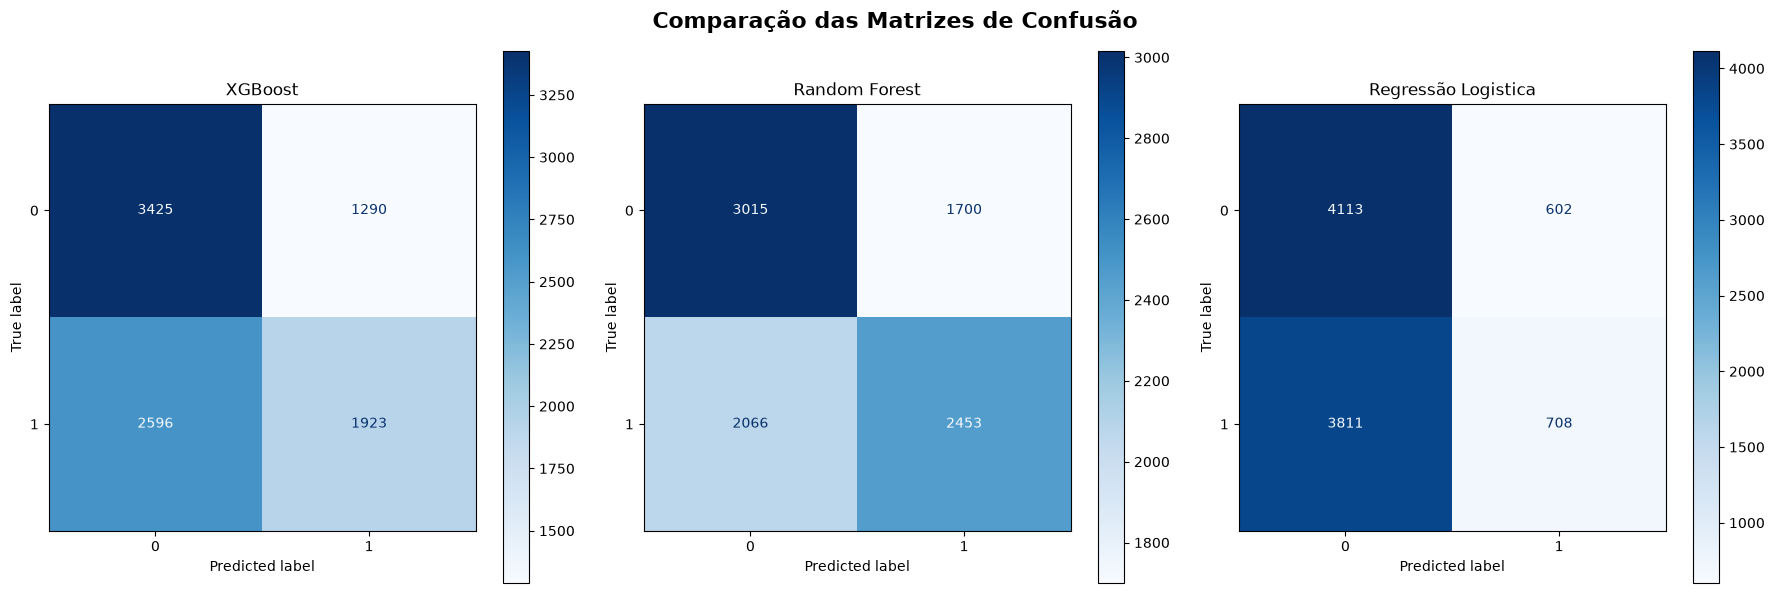

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
ConfusionMatrixDisplay.from_estimator(modelo_xgb_final, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[0], colorbar=True)
ax[0].set_title("XGBoost")

# Random Forest
ConfusionMatrixDisplay.from_estimator(modelo_rf_final, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[1], colorbar=True)
ax[1].set_title("Random Forest")

# KNN
ConfusionMatrixDisplay.from_estimator(modelo_rl_final, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[2], colorbar=True)
ax[2].set_title("Regressão Logistica")

# Titulo geral
plt.suptitle("Comparação das Matrizes de Confusão", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

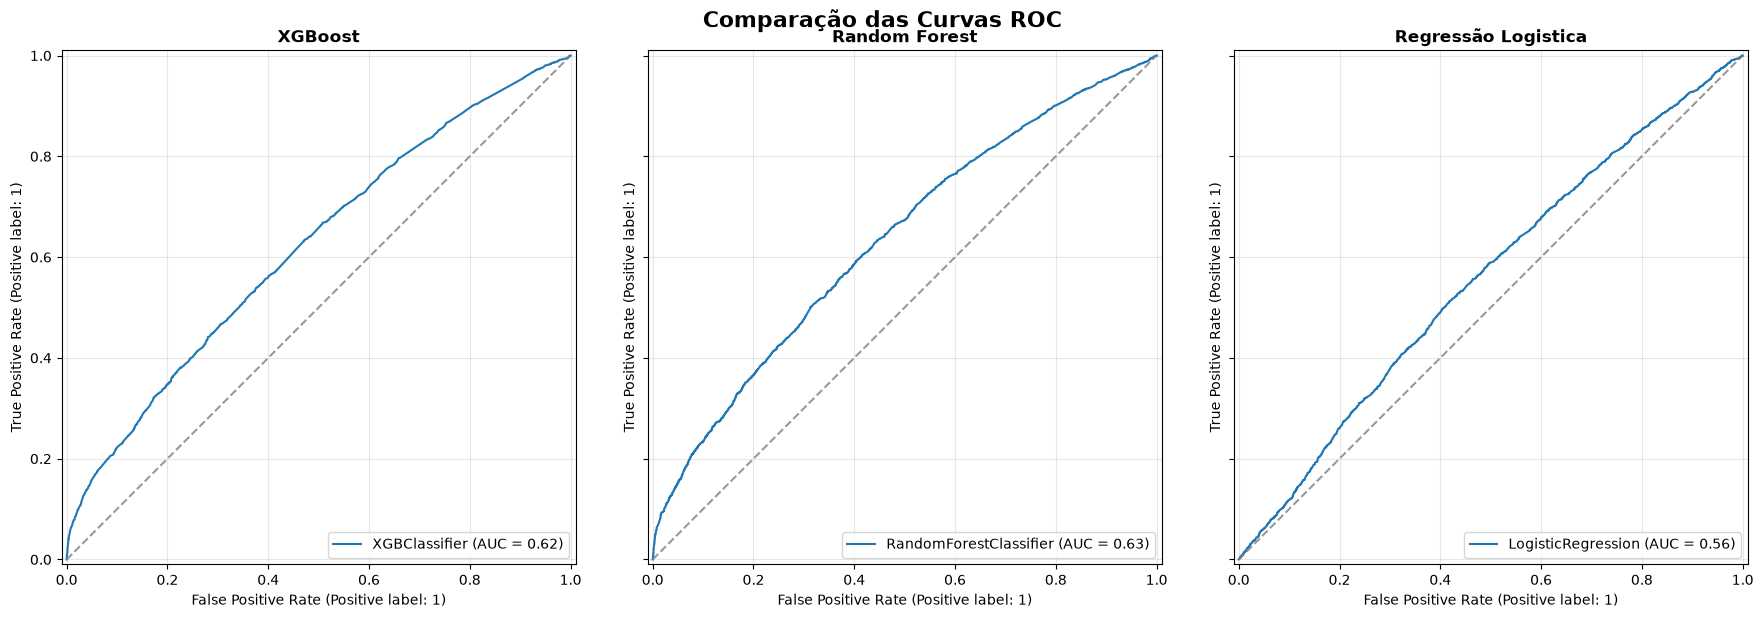

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# XGBoost
RocCurveDisplay.from_estimator(modelo_xgb_final, X_validacao_variance, y_validacao, ax=ax[0])
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[0].set_title("XGBoost", fontweight="bold")
ax[0].grid(alpha=0.3)

# Random Forest
RocCurveDisplay.from_estimator(modelo_rf_final, X_validacao_variance, y_validacao, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Random Forest", fontweight="bold")
ax[1].grid(alpha=0.3)

# KNN 
RocCurveDisplay.from_estimator(modelo_rl_final, X_validacao_variance, y_validacao, ax=ax[2])
ax[2].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[2].set_title("Regressão Logistica", fontweight="bold")
ax[2].grid(alpha=0.3)

plt.suptitle("Comparação das Curvas ROC", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

# 11. Ensemble com Voting Classifier

Com base nos resultados obtidos após a otimização dos modelos, Random Forest e XGBoost foram selecionados para compor um ensemble.

O Voting Classifier combina as previsões de diferentes algoritmos com o objetivo de reduzir limitações individuais e melhorar a capacidade de generalização.

Como ambos os modelos utilizados fornecem probabilidades de classificação, será utilizado o método de votação `soft`, no qual a decisão final é baseada na média das probabilidades previstas por cada modelo.

In [30]:
from sklearn.ensemble import VotingClassifier

modelo_voting = VotingClassifier(
    estimators=[
        ("random_forest", modelo_rf_final),
        ("xgboost", modelo_xgb_final)
    ],
    voting="soft",
    n_jobs=-1
)

In [31]:
modelo_voting.fit(X_treino_variance, y_treino)

pred_voting = modelo_voting.predict(X_validacao_variance)

In [32]:
print("Modelo Voting:")
print(classification_report(y_validacao, pred_voting))

Modelo Voting:
              precision    recall  f1-score   support

           0       0.58      0.68      0.63      4715
           1       0.60      0.49      0.54      4519

    accuracy                           0.59      9234
   macro avg       0.59      0.59      0.58      9234
weighted avg       0.59      0.59      0.58      9234



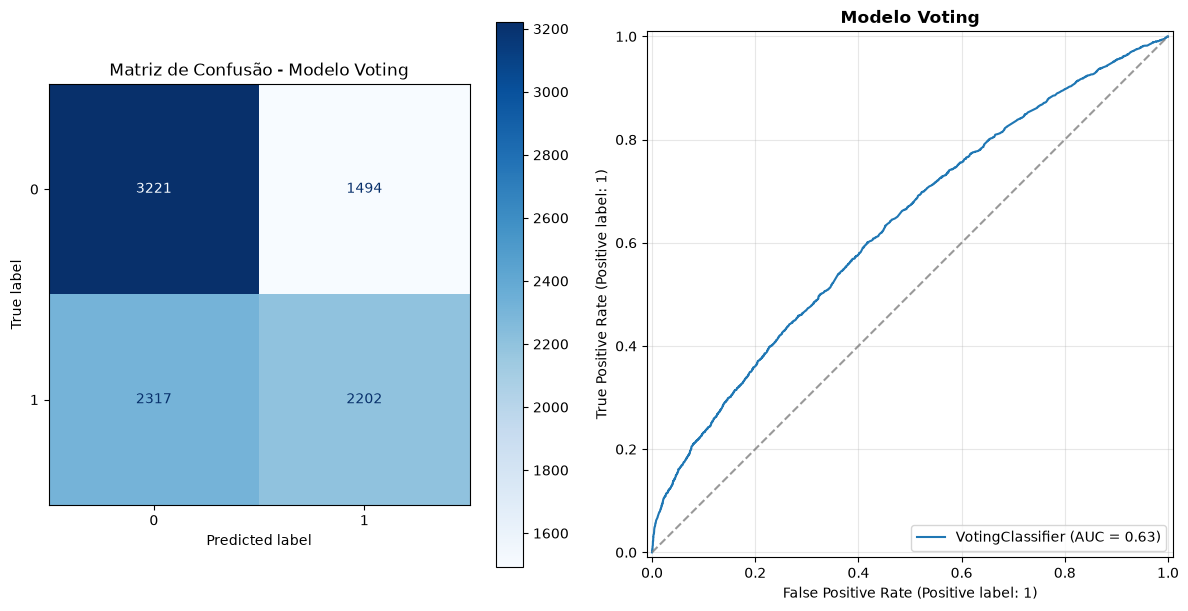

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Matriz de Confusão
ConfusionMatrixDisplay.from_estimator(modelo_voting, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusão - Modelo Voting")

# Curva ROC
RocCurveDisplay.from_estimator(modelo_voting, X_validacao_variance, y_validacao, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Modelo Voting", fontweight="bold")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 12. Ensemble com Stacking Classifier

Após a avaliação do Voting Classifier, foi testada uma estratégia de ensemble baseada em Stacking.

Nesse método, as previsões dos modelos base são utilizadas como entrada para um segundo modelo, denominado meta-modelo.

Foram utilizados como modelos base o Random Forest e o XGBoost, enquanto uma Regressão Logística foi utilizada como meta-modelo.

O objetivo é verificar se a combinação aprendida entre os modelos consegue produzir melhor equilíbrio entre as classes e maior capacidade de generalização do que os classificadores individuais.

In [34]:
from sklearn.ensemble import StackingClassifier

modelo_stacking = StackingClassifier(
    estimators=[
        ("random_forest", modelo_rf_final),
        ("xgboost", modelo_xgb_final)
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=3000),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1,
    passthrough=False
)

In [35]:
modelo_stacking.fit(X_treino_variance, y_treino)

pred_stacking = modelo_stacking.predict(X_validacao_variance)

proba_stacking = modelo_stacking.predict_proba(
    X_validacao_variance
)[:, 1]

In [36]:
print("Modelo Stacking")
print(classification_report(y_validacao, pred_stacking))

Modelo Stacking
              precision    recall  f1-score   support

           0       0.59      0.62      0.61      4715
           1       0.59      0.56      0.57      4519

    accuracy                           0.59      9234
   macro avg       0.59      0.59      0.59      9234
weighted avg       0.59      0.59      0.59      9234



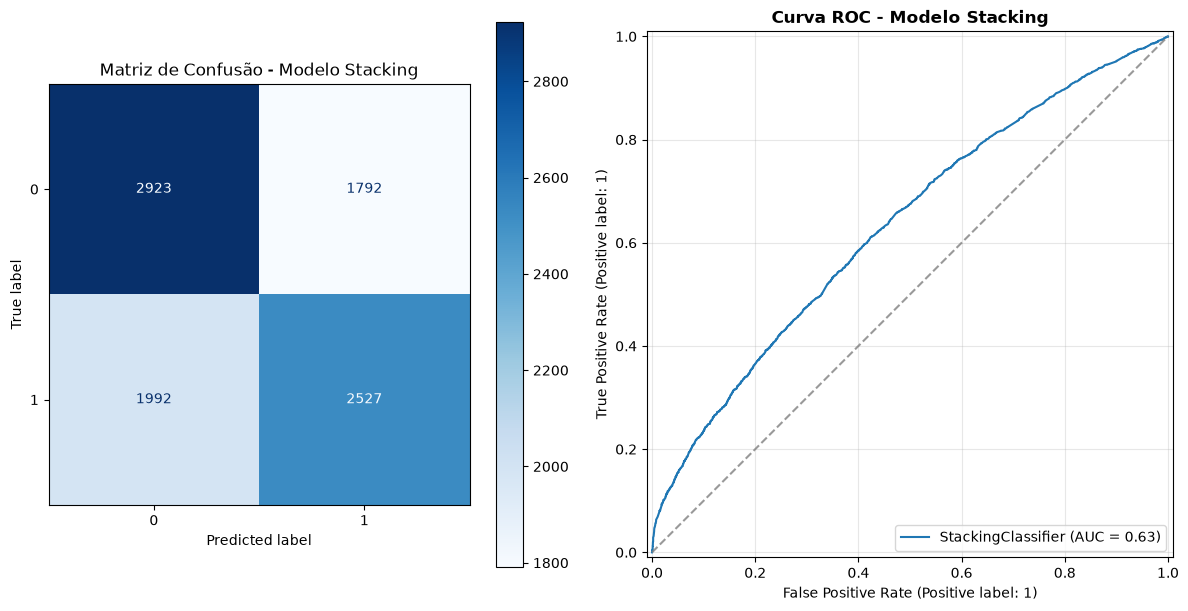

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Matriz de Confusão
ConfusionMatrixDisplay.from_estimator(modelo_stacking, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusão - Modelo Stacking")

# Curva ROC
RocCurveDisplay.from_estimator(modelo_stacking, X_validacao_variance, y_validacao, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Curva ROC - Modelo Stacking", fontweight="bold")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparação consolidada dos modelos

Após o treinamento e otimização dos modelos, os classificadores individuais e os ensembles são reunidos em uma única comparação.

Essa consolidação permite avaliar, de forma padronizada, o desempenho de cada abordagem sobre o mesmo conjunto de validação, considerando métricas globais e específicas para cada classe.

In [38]:
modelos_comparacao = {
    "XGBoost Tunado": random_xgb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "Regressão Logística Tunada": random_rl.best_estimator_,
    "Voting": modelo_voting,
    "Stacking": modelo_stacking
}

resultados_comparacao = []

for nome, modelo in modelos_comparacao.items():
    
    pred = modelo.predict(X_validacao_variance)
    proba = modelo.predict_proba(X_validacao_variance)[:, 1]
    
    resultados_comparacao.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_validacao, pred),
        "Recall_0": recall_score(y_validacao, pred, pos_label=0),
        "Recall_1": recall_score(y_validacao, pred, pos_label=1),
        "Precision_0": precision_score(y_validacao, pred, pos_label=0),
        "Precision_1": precision_score(y_validacao, pred, pos_label=1),
        "F1_0": f1_score(y_validacao, pred, pos_label=0),
        "F1_1": f1_score(y_validacao, pred, pos_label=1),
        "F1_Macro": f1_score(y_validacao, pred, average="macro"),
        "ROC_AUC": roc_auc_score(y_validacao, proba)
    })

resultados_comparacao_df = (pd.DataFrame(resultados_comparacao).sort_values(by="F1_Macro", ascending=False).reset_index(drop=True))

resultados_comparacao_df.round(4)

,Modelo,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1_0,F1_1,F1_Macro,ROC_AUC
0,Random Forest Tunado,0.5922,0.6394,0.5428,0.5934,0.5907,0.6156,0.5657,0.5906,0.6337
1,Stacking,0.5902,0.6199,0.5592,0.5947,0.5851,0.6071,0.5718,0.5895,0.6323
2,Voting,0.5873,0.6831,0.4873,0.5816,0.5958,0.6283,0.5361,0.5822,0.6300
3,XGBoost Tunado,0.5792,0.7264,0.4255,0.5688,0.5985,0.6380,0.4974,0.5677,0.6199
4,Regressão Logística Tunada,0.5221,0.8723,0.1567,0.5191,0.5405,0.6508,0.2429,0.4469,0.5562


### Seleção do modelo candidato final

A comparação entre os modelos demonstrou que o Random Forest Tunado apresentou o melhor equilíbrio geral entre as classes.

Embora outros modelos tenham alcançado maior Recall para a classe 0, esse ganho ocorreu acompanhado de redução significativa no desempenho da classe 1. O Random Forest, por outro lado, apresentou o maior F1-Macro e a maior AUC-ROC entre os modelos avaliados, mantendo desempenho mais equilibrado entre alunos alfabetizados e não alfabetizados.

Além disso, os modelos de ensemble Voting e Stacking não apresentaram ganhos relevantes em relação ao Random Forest, apesar de adicionarem maior complexidade ao processo de modelagem.

Dessa forma, o Random Forest Tunado foi selecionado como modelo candidato final para a etapa de ajuste do threshold de classificação.

In [39]:
proba_rf = modelo_rf_final.predict_proba(
    X_validacao_variance
)[:, 1]

In [40]:
thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

resultados_threshold = []

for threshold in thresholds:
    
    pred_threshold = (
        proba_rf >= threshold
    ).astype(int)
    
    resultados_threshold.append({
        "Threshold": threshold,
        
        "Acurácia": accuracy_score(y_validacao, pred_threshold),
                
        "Recall_0": recall_score(y_validacao, pred_threshold, pos_label=0),
        
        "Recall_1": recall_score(y_validacao, pred_threshold, pos_label=1),
        
        "Precision_0": precision_score(y_validacao, pred_threshold, pos_label=0),
        
        "Precision_1": precision_score(y_validacao, pred_threshold, pos_label=1),
        
        "F1_0": f1_score(y_validacao, pred_threshold, pos_label=0),
        
        "F1_1": f1_score(y_validacao, pred_threshold, pos_label=1),
        
        "F1_Macro": f1_score(y_validacao, pred_threshold, average="macro")
    })

df_threshold = pd.DataFrame(
    resultados_threshold
)

df_threshold.round(4)

,Threshold,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1_0,F1_1,F1_Macro
0,0.40,0.5330,0.1574,0.9250,0.6864,0.5127,0.2560,0.6597,0.4579
1,0.45,0.5696,0.3404,0.8088,0.6501,0.5403,0.4468,0.6478,0.5473
2,0.50,0.5922,0.6394,0.5428,0.5934,0.5907,0.6156,0.5657,0.5906
3,0.55,0.5690,0.9302,0.1921,0.5457,0.7251,0.6879,0.3037,0.4958
4,0.60,0.5417,0.9860,0.0781,0.5274,0.8425,0.6872,0.1430,0.4151
5,0.65,0.5363,0.9922,0.0606,0.5243,0.8810,0.6860,0.1135,0.3997
6,0.70,0.5297,0.9955,0.0436,0.5206,0.9037,0.6837,0.0832,0.3834


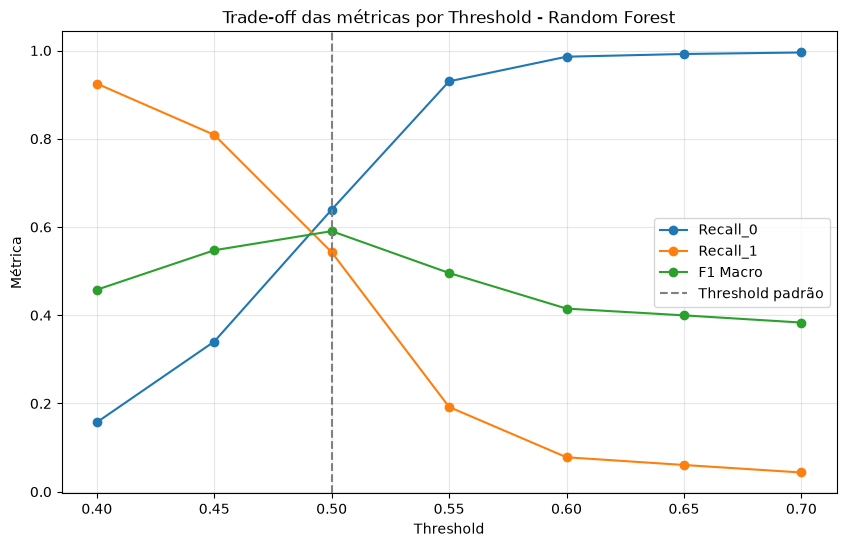

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(df_threshold["Threshold"], df_threshold["Recall_0"], marker="o", label="Recall_0")

plt.plot(df_threshold["Threshold"], df_threshold["Recall_1"], marker="o", label="Recall_1")


plt.plot(df_threshold["Threshold"], df_threshold["F1_Macro"], marker="o", label="F1 Macro")

plt.axvline(x=0.50, color="gray", linestyle="--", label="Threshold padrão")

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Trade-off das métricas por Threshold - Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [42]:
thresholds = [0.50, 0.51, 0.52, 0.53, 0.54, 0.55]

resultados_threshold_fino  = []

for threshold in thresholds:
    
    pred_threshold = (
        proba_rf >= threshold
    ).astype(int)
    
    resultados_threshold_fino .append({
        "Threshold": threshold,
        
        "Acurácia": accuracy_score(y_validacao, pred_threshold),
                
        "Recall_0": recall_score(y_validacao, pred_threshold, pos_label=0),
        
        "Recall_1": recall_score(y_validacao, pred_threshold, pos_label=1),
        
        "Precision_0": precision_score(y_validacao, pred_threshold, pos_label=0),
        
        "Precision_1": precision_score(y_validacao, pred_threshold, pos_label=1),
        
        "F1_0": f1_score(y_validacao, pred_threshold, pos_label=0),
        
        "F1_1": f1_score(y_validacao, pred_threshold, pos_label=1),
        
        "F1_Macro": f1_score(y_validacao, pred_threshold, average="macro")
    })

df_threshold_fino = pd.DataFrame(
    resultados_threshold_fino 
)

df_threshold_fino.round(4)

,Threshold,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1_0,F1_1,F1_Macro
0,0.50,0.5922,0.6394,0.5428,0.5934,0.5907,0.6156,0.5657,0.5906
1,0.51,0.5888,0.7169,0.4552,0.5786,0.6064,0.6403,0.5200,0.5802
2,0.52,0.5891,0.7826,0.3873,0.5713,0.6306,0.6605,0.4798,0.5702
3,0.53,0.5826,0.8392,0.3149,0.5610,0.6525,0.6725,0.4248,0.5486
4,0.54,0.5765,0.8918,0.2474,0.5529,0.6867,0.6826,0.3638,0.5232
5,0.55,0.5690,0.9302,0.1921,0.5457,0.7251,0.6879,0.3037,0.4958


### Seleção do threshold operacional

Considerando que o principal objetivo do modelo é apoiar a identificação de alunos potencialmente não alfabetizados, foi priorizado o Recall da classe 0.

A análise dos thresholds demonstrou que o valor padrão de 0,50 apresenta o melhor equilíbrio geral entre as classes. Entretanto, o threshold de **0,52** proporcionou aumento relevante na capacidade de identificação dos alunos não alfabetizados, elevando o Recall da classe 0 de aproximadamente **63,9% para 78,3%**.

Esse ganho ocorreu com pequena redução da acurácia global e aumento do F1-score da classe 0, embora acompanhado de redução na capacidade de identificação da classe 1.

Dessa forma, o threshold de **0,52** foi selecionado como limiar operacional, considerando o modelo como uma ferramenta de triagem e priorização de alunos que podem demandar acompanhamento pedagógico adicional.

O threshold padrão de 0,50 permanece como referência para cenários em que se deseja maior equilíbrio entre as duas classes.

### Validação cruzada do modelo final

Após a seleção do Random Forest como modelo candidato final, foi realizada uma validação cruzada estratificada com 5 folds sobre os dados de desenvolvimento.

Nesta etapa, os conjuntos de treino e validação foram combinados, enquanto o conjunto de teste permaneceu isolado para a avaliação final.

A validação cruzada permite verificar a estabilidade do modelo em diferentes subdivisões dos dados, reduzindo a dependência de uma única partição e fornecendo uma estimativa mais robusta de desempenho.

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = {
    "accuracy": "accuracy",
    "recall_0": make_scorer(recall_score, pos_label=0),
    "recall_1": make_scorer(recall_score, pos_label=1),
    "f1_0": make_scorer(f1_score, pos_label=0),
    "f1_1": make_scorer(f1_score, pos_label=1),
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc"
}

cv_resultados = cross_validate(
    estimator=modelo_rf_final,
    X = X_treino_variance,
    y = y_treino,
    cv=cv,
    scoring=metricas,
    n_jobs=-1
)

In [44]:
cv_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Recall_0", "Recall_1", "F1_0", "F1_1", "F1_Macro", "ROC_AUC"],
    
    "Média": [
        cv_resultados["test_accuracy"].mean(),
        cv_resultados["test_recall_0"].mean(),
        cv_resultados["test_recall_1"].mean(),
        cv_resultados["test_f1_0"].mean(),
        cv_resultados["test_f1_1"].mean(),
        cv_resultados["test_f1_macro"].mean(),
        cv_resultados["test_roc_auc"].mean()
    ],
    
    "Desvio padrão": [
        cv_resultados["test_accuracy"].std(),
        cv_resultados["test_recall_0"].std(),
        cv_resultados["test_recall_1"].std(),
        cv_resultados["test_f1_0"].std(),
        cv_resultados["test_f1_1"].std(),
        cv_resultados["test_f1_macro"].std(),
        cv_resultados["test_roc_auc"].std()
    ]
})

cv_df.round(4)

,Métrica,Média,Desvio padrão
0,Accuracy,0.5901,0.0022
1,Recall_0,0.6514,0.0127
2,Recall_1,0.5261,0.0147
3,F1_0,0.6187,0.0046
4,F1_1,0.5567,0.0075
5,F1_Macro,0.5877,0.0026
6,ROC_AUC,0.6290,0.0043


### Avaliação final com threshold operacional

Após a validação cruzada, o Random Forest apresentou desempenho estável entre diferentes partições dos dados de desenvolvimento, com baixa variação nas principais métricas.

Considerando o objetivo do projeto de priorizar a identificação de alunos potencialmente não alfabetizados, foi definido anteriormente o threshold operacional de **0,52**.

O conjunto de teste, mantido isolado durante as etapas de treinamento, seleção de modelo e definição do threshold, é utilizado agora exclusivamente para estimar o desempenho final e a capacidade de generalização do modelo.

In [45]:
threshold_final = 0.52

proba_teste = modelo_rf_final.predict_proba(X_teste_variance)[:, 1]

pred_teste_final = (proba_teste >= threshold_final).astype(int)

In [46]:
print("Modelo Final - Threshold 0.52")
print(classification_report(y_teste, pred_teste_final))

Modelo Final - Threshold 0.52
              precision    recall  f1-score   support

           0       0.56      0.78      0.66      5894
           1       0.62      0.37      0.46      5649

    accuracy                           0.58     11543
   macro avg       0.59      0.58      0.56     11543
weighted avg       0.59      0.58      0.56     11543



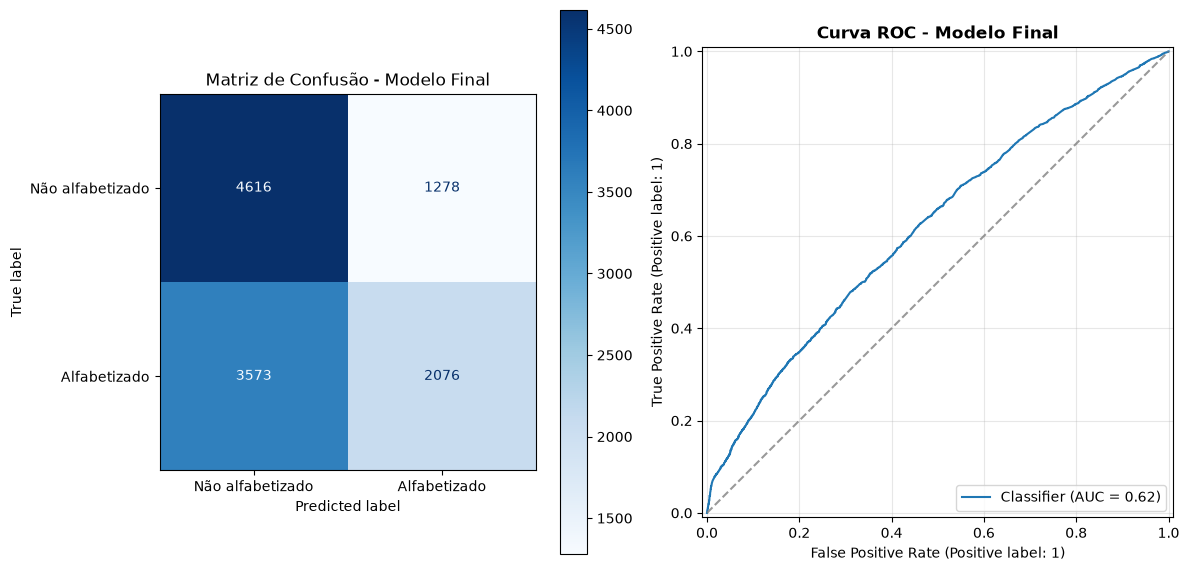

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(y_teste, pred_teste_final, display_labels=["Não alfabetizado", "Alfabetizado"], cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusão - Modelo Final")

# Curva Roc
RocCurveDisplay.from_predictions(y_teste, proba_teste, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Curva ROC - Modelo Final", fontweight="bold")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Resultado final do modelo

O Random Forest final foi avaliado no conjunto de teste utilizando o threshold operacional de **0,52**, definido previamente a partir do conjunto de validação.

O modelo apresentou Recall de aproximadamente **78% para a classe de alunos não alfabetizados**, indicando boa capacidade de identificação da população de maior interesse do projeto.

Esse ganho de sensibilidade ocorre com redução no Recall da classe alfabetizada, evidenciando o trade-off assumido pela estratégia de priorização da classe 0.

A curva ROC apresentou AUC de aproximadamente **0,62**, indicando capacidade discriminatória moderada.

Dessa forma, o modelo final é interpretado como uma ferramenta de **triagem e priorização de alunos potencialmente não alfabetizados**, podendo apoiar ações pedagógicas e análises adicionais, sem substituir avaliações educacionais individuais.

# 13. Feature Importance - Modelo Final (Random Forest)

In [48]:
X_teste_variance_df = pd.DataFrame(
    X_teste_variance,
    columns=features_variance
)

In [49]:
importance_rf = pd.DataFrame({
    "feature": X_teste_variance_df.columns,
    "importance": modelo_rf_final.feature_importances_
})

importance_rf = importance_rf.sort_values("importance", ascending=False)
print(importance_rf.head(10))

                               feature  importance
23                         sigla_uf_CE    0.238970
22                         sigla_uf_BA    0.114158
5                    qtd_escolas_censo    0.057084
12  prop_escolas_internet_aprendizagem    0.054245
11               prop_escolas_internet    0.051593
4                densidade_demografica    0.039618
9      prop_escolas_biblioteca_leitura    0.038100
7            prop_escolas_agua_potavel    0.036578
2                       populacao_2022    0.035354
43                        regiao_Norte    0.033950


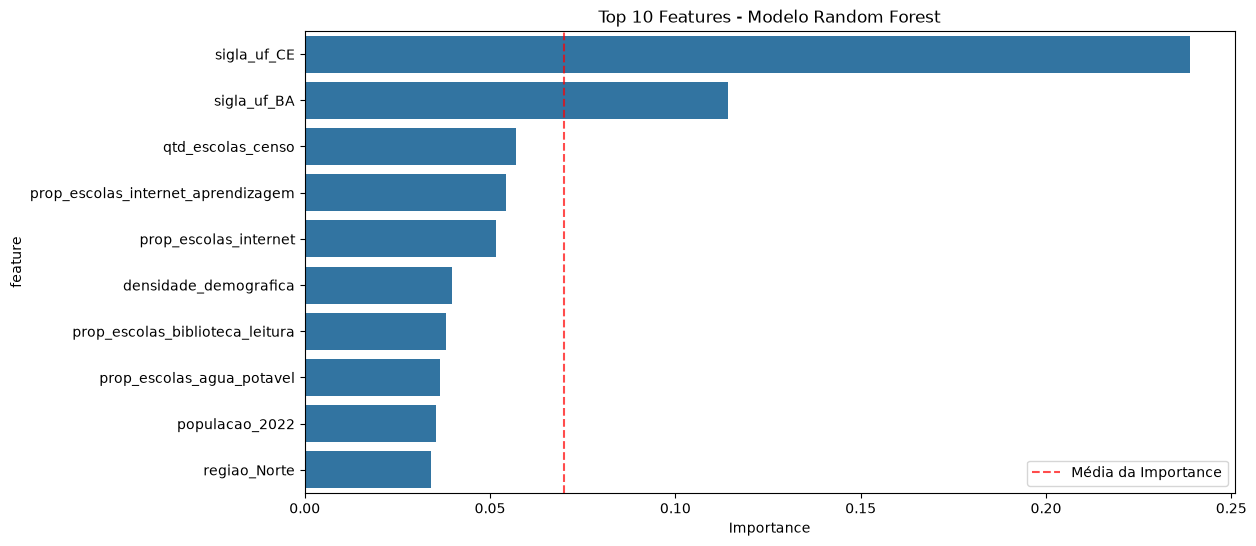

In [50]:
top_10_rf = importance_rf.head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_10_rf['importance'], y=top_10_rf['feature'])
plt.axvline(top_10_rf['importance'].mean(), color='red', linestyle='--', alpha=0.7, label='Média da Importance')

plt.xlabel("Importance")
plt.title("Top 10 Features - Modelo Random Forest")
plt.legend()
plt.show()


# 14. Interpretabilidade do modelo com SHAP

Após a seleção e avaliação do Random Forest final, foi aplicada a técnica SHAP (SHapley Additive exPlanations) para interpretar as previsões realizadas pelo modelo.

O SHAP permite analisar tanto a importância global das variáveis quanto a contribuição individual de cada feature para uma determinada previsão.

Como o objetivo principal deste projeto é identificar alunos potencialmente **não alfabetizados**, as análises SHAP serão direcionadas para a **classe 0 — Não alfabetizado**.

Valores SHAP positivos indicam contribuição para aumentar a saída do modelo em direção à classe 0, enquanto valores negativos indicam contribuição no sentido contrário.

In [51]:
import shap

In [58]:
# Criando o explainer específico para o Random Forest
explainer = shap.TreeExplainer(modelo_rf_final)

# Calculando os valores SHAP para o conjunto de teste
shap_values = explainer.shap_values(X_teste_variance_df)

print("Shape X_teste:", X_teste_variance_df.shape)
print("Shape SHAP:", np.asarray(shap_values).shape)

Shape X_teste: (11543, 46)
Shape SHAP: (11543, 46, 2)


In [59]:
# Selecionando os valores SHAP referentes à classe 0
# Classe 0 = Não alfabetizado
shap_values_classe_0 = shap_values[:, :, 0]

print(f"Shape SHAP - Classe 0: {shap_values_classe_0.shape}")

Shape SHAP - Classe 0: (11543, 46)


### 14.2 Importância global das variáveis

Inicialmente, é analisada a importância global das features para a previsão da classe de alunos não alfabetizados.

O gráfico apresenta a magnitude média absoluta dos valores SHAP de cada variável. Quanto maior o valor, maior a influência daquela feature sobre as previsões realizadas pelo modelo.

Essa análise representa importância preditiva e não deve ser interpretada como relação causal.

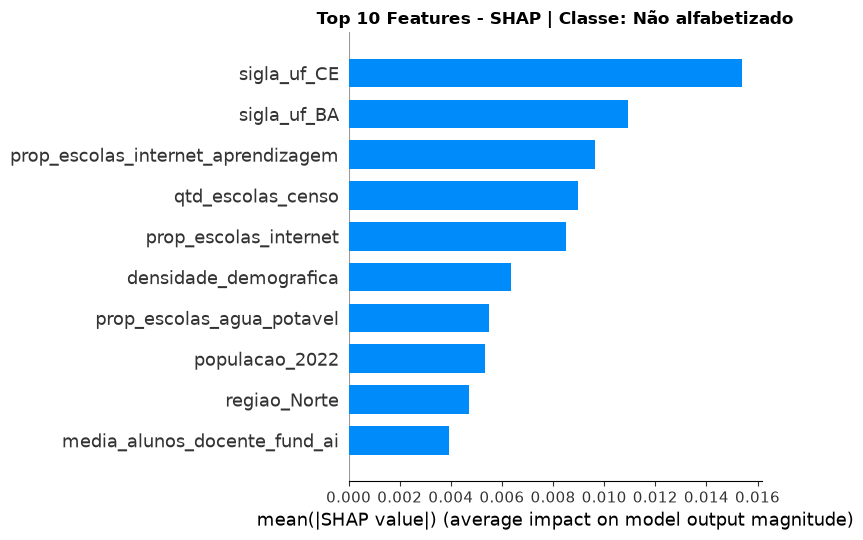

In [60]:
shap.summary_plot(
    shap_values_classe_0,
    X_teste_variance_df,
    max_display=10,
    plot_type="bar",
    show=False
)

plt.title("Top 10 Features - SHAP | Classe: Não alfabetizado", fontweight="bold")

plt.tight_layout()
plt.show()

### 14.3 Distribuição e direção do impacto das features

Além da importância global, o SHAP permite analisar a direção e a intensidade da contribuição de cada variável.

No gráfico a seguir:

- o eixo horizontal representa o valor SHAP;
- valores positivos aumentam a saída do modelo em direção à classe **Não alfabetizado**;
- valores negativos reduzem essa tendência;
- cada ponto representa uma observação;
- a cor representa o valor assumido pela própria feature.

Dessa forma, é possível analisar não apenas quais variáveis são importantes, mas também como diferentes valores dessas variáveis influenciam as previsões.

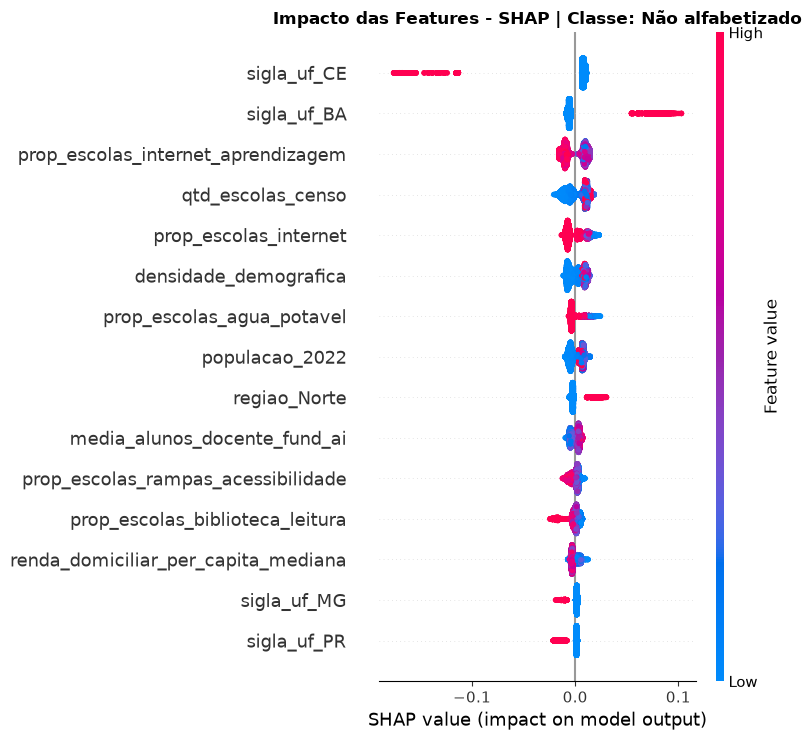

In [61]:
shap.summary_plot(
    shap_values_classe_0,
    X_teste_variance_df,
    max_display=15,
    show=False
)

plt.title("Impacto das Features - SHAP | Classe: Não alfabetizado", fontweight="bold")

plt.tight_layout()
plt.show()

### 14.4 Análise de dependência das principais variáveis

Os gráficos de dependência SHAP permitem investigar como diferentes valores de uma feature estão associados à contribuição dessa variável para a previsão do modelo.

Essa análise é especialmente útil para variáveis numéricas contínuas, pois permite identificar relações não lineares, mudanças de comportamento e possíveis interações entre features.

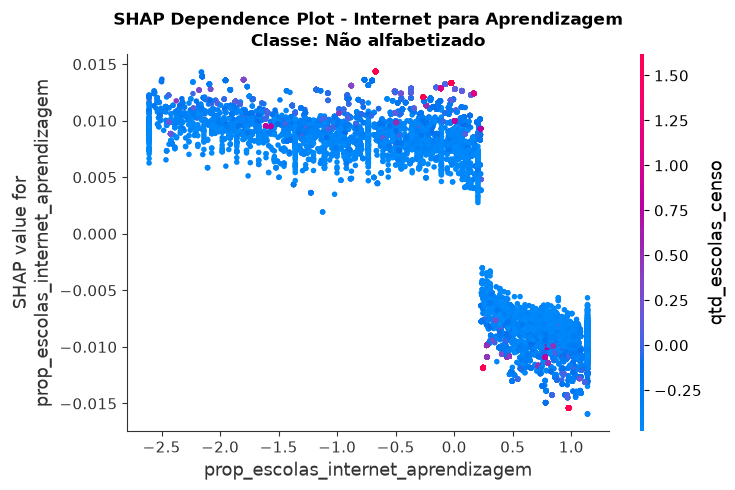

In [62]:
feature_dependence = "prop_escolas_internet_aprendizagem"

shap.dependence_plot(
    feature_dependence,
    shap_values_classe_0,
    X_teste_variance_df,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependence Plot - Internet para Aprendizagem\n"
    "Classe: Não alfabetizado",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 14.5 Explicação individual de uma previsão

Além da interpretação global, o SHAP permite explicar individualmente a previsão realizada para cada aluno.

O gráfico Waterfall parte do valor esperado do modelo e apresenta como cada variável contribuiu positiva ou negativamente para a saída referente à classe de interesse.

Nesta análise, será utilizada a classe **0 — Não alfabetizado**.

In [63]:
target_descriptions = {
    0: "Não Alfabetizado",
    1: "Alfabetizado"
}

indice_aluno = 3

aluno_df = X_teste_variance_df.iloc[[indice_aluno]]

classe_real = y_teste.iloc[indice_aluno]

classe_prevista = modelo_rf_final.predict(aluno_df)[0]

probabilidades = modelo_rf_final.predict_proba(aluno_df)[0]

print(
    f"Classe Real : {classe_real} - "
    f"{target_descriptions[classe_real]}"
)

print(
    f"Classe Prevista: {classe_prevista} - "
    f"{target_descriptions[classe_prevista]}"
)

print(
    f"Probabilidades: {probabilidades}"
)

Classe Real : 0 - Não Alfabetizado
Classe Prevista: 0 - Não Alfabetizado
Probabilidades: [0.57631006 0.42368994]


c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


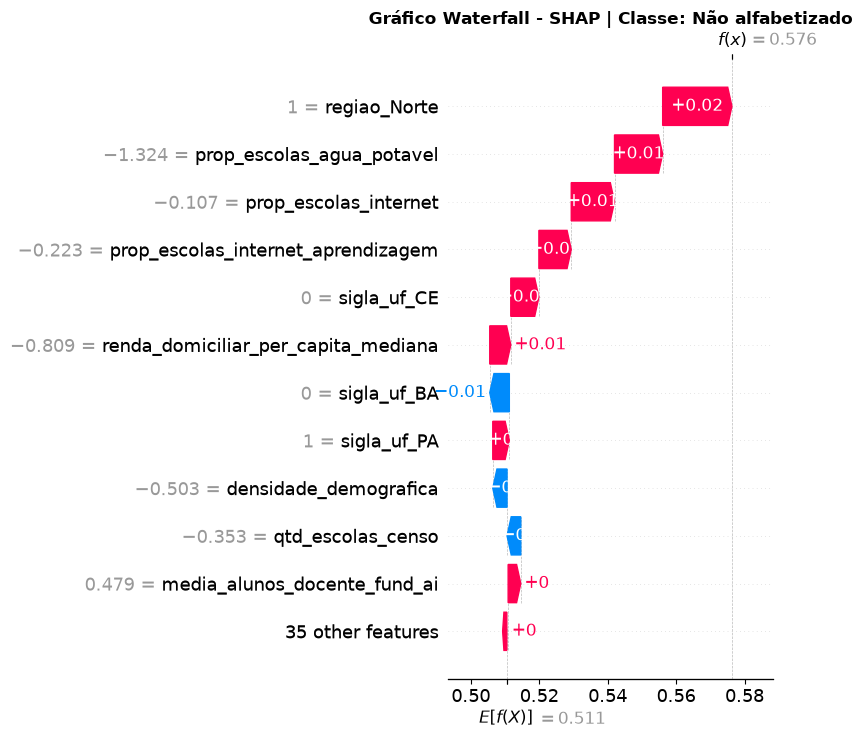

In [64]:
# Visualizando gráfico de Waterfall
explanation_cliente = shap.Explanation(
    values=shap_values_classe_0[indice_aluno],
    base_values=np.asarray(explainer.expected_value)[0],
    data=aluno_df.iloc[0].values,
    feature_names=aluno_df.columns.tolist()
)

shap.plots.waterfall(
    explanation_cliente,
    max_display=12,
    show=False
)

plt.title(
    "Gráfico Waterfall - SHAP | Classe: Não alfabetizado",
    fontweight="bold"
)

plt.tight_layout()
plt.show()